# 06 ゲイトモード（S4）

## 背景

05 の制御器（EqualShare + 高さ P + 立脚 \(h-J^{\top}F\) + 遊脚 \(+J^{\top}\) PD）は**変えない**。この段の新しい現象は、**位相オフセットと duty / 周波数だけ**で運びが変わることである（[S4](../docs/block-curriculum/02_Stage_Ladder.md)、[06](../docs/block-curriculum/06_Gait_Modes.md)）。`if gait == "trot"` は書かない。

offset の数字は上流 PyMPC `PeriodicGaitGenerator` から写す。EqualShare は 2 脚の左右（pace）や前後（bound）に弱いので、duty を上げて overlap を残す。duty もゲイトパラメータである。

### 成功条件（数値。ここが合否）

[README §3.8](../docs/block-curriculum/00_README.md)。**各モードで連続 5.0 秒。** \(T=7.0\,\mathrm{s}\)。

| 量 | 全モード |
|---|---|
| \(\lvert\mathrm{roll}\rvert,\lvert\mathrm{pitch}\rvert\) | \(<0.35\,\mathrm{rad}\) |
| \(\lVert xy-xy_0\rVert\) | \(<0.30\,\mathrm{m}\) |
| \(z\) | \(>0.20\,\mathrm{m}\) |
| `qpos` | 有限 |
| hold | \(\ge 5.0\,\mathrm{s}\) |

加えて:

| モード | 追加 |
|---|---|
| `full_stance` | 実測空中 \(<0.05\,\mathrm{s}/\)脚（足が上がらない確認） |
| `trot` | 実測空中 \(\ge 0.15\,\mathrm{s}/\)脚。対角ペア指令が両方 |
| `crawl` / `pace` / `bound` | 指令 \(c(t)\) が offset どおり（4 本線の図）。空中は duty が高いので短くてよい |

PyMPC 既定の低い duty のまま pace すると転ぶ。その失敗 GIF は残す。満たすまで 07 へ進まない。

## 目的

- 同じ \(\tau\) の式で、offset がトロットとペースを分けることを見る
- `full_stance` が S1 に戻ること
- 接地の 4 本線をモードごとに残す

## 数式

$$
\phi_i\leftarrow(\phi_i+\Delta t\,f)\bmod 1,\qquad c_i=[\phi_i<d]
$$

違うのは \(\phi_i(0)\)（offset）と \(f,d\) だけである。

## 図

```
gait name --> (f, d, offset) --> c(t) --> 05 と同じ tau
```

## 仮説

1. PyMPC 既定 duty（pace 0.70 など）では EqualShare のまま転ぶ
2. duty を上げ、offset だけモードどおりにすれば、5 秒持てる


In [1]:
# --- このセルの意図 ---
# S4: 05 の tau をそのまま。変えるのは freq, duty, offset の表だけ。

from pathlib import Path
import sys
import numpy as np
import mujoco
import matplotlib.pyplot as plt
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

HOLD_S = 5.0
ATT_TOL = 0.35
XY_TOL = 0.30
Z_MIN = 0.20
T_RUN = 7.0
KP_SW, KD_SW = 300.0, 20.0
STEP_H = 0.02
KP_Z, KD_Z = 8000.0, 400.0

# 内容: offset は PyMPC PeriodicGaitGenerator。duty は EqualShare が持つ値（ゲイトパラメータ）。
GAITS = {
    "full_stance": {"freq": 1.0, "duty": 1.00, "off": np.array([0.0, 0.0, 0.0, 0.0])},
    "trot": {"freq": 1.0, "duty": 0.96, "off": np.array([0.5, 1.0, 1.0, 0.5])},
    "crawl": {"freq": 1.0, "duty": 0.98, "off": np.array([0.0, 0.5, 0.75, 0.25])},
    "pace": {"freq": 1.0, "duty": 0.995, "off": np.array([0.8, 0.3, 0.8, 0.3])},
    "bound": {"freq": 1.0, "duty": 0.995, "off": np.array([0.5, 0.5, 0.0, 0.0])},
}

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 の飽和。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の 3x3 足ヤコビ。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def rollout(freq, duty, off, T=T_RUN):
    """意図: ゲイト数字以外は 05 試行 4 と同じ。
    内容: 戻りに hold と指令 c の時系列を入れる（4 本線用）。"""
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt
    n = int(round(T / dt))
    geoms = p.foot_geom_ids()
    z0 = float(p.base_pos()[2])
    xy0 = p.base_pos()[:2].copy()
    mg = p.mass_kg * 9.81
    phi = np.asarray(off, dtype=np.float64).copy()
    lift = p.feet_pos_world().copy()
    prev = np.ones(4)
    ok, cs, meas_air = [], [], np.zeros(4)
    zmin, maxr, maxxy = z0, 0.0, 0.0
    for _k in range(n):
        phi = (phi + dt * freq) % 1.0
        c = (phi < duty).astype(float)  # 内容: offset が脚の組を決める。名前では分岐しない
        ns = max(float(c.sum()), 1.0)
        z = float(p.base_pos()[2])
        vz = float(p.base_lin_vel_world()[2])
        fz_tot = mg + KP_Z * (z0 - z) - KD_Z * vz
        feet = p.feet_pos_world()
        vel = p.feet_vel_world()
        h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)
        tau = np.zeros(12)
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5:
                lift[i] = feet[i].copy()
            Jleg = jac_leg(p.model, p.data, geoms, i)
            sl = slice(3 * i, 3 * i + 3)
            if c[i] > 0.5:
                tau[sl] = h[sl] - Jleg.T @ np.array([0.0, 0.0, fz_tot / ns])
            else:
                s = float(np.clip((phi[i] - duty) / max(1e-6, 1.0 - duty), 0.0, 1.0))
                w = freq / max(1e-6, 1.0 - duty)
                p_d = lift[i].copy()
                p_d[2] = lift[i, 2] + STEP_H * np.sin(np.pi * s)
                v_d = np.zeros(3)
                v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
                tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
        p.step(clip_torque(tau, p.model.actuator_ctrlrange))
        prev = c
        cs.append(c.copy())
        rpy = p.base_rpy()
        xy = p.base_pos()[:2]
        z = float(p.base_pos()[2])
        maxr = max(maxr, abs(rpy[0]), abs(rpy[1]))
        maxxy = max(maxxy, float(np.linalg.norm(xy - xy0)))
        zmin = min(zmin, z)
        ok.append(abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL and float(np.linalg.norm(xy - xy0)) < XY_TOL and z > Z_MIN and bool(np.isfinite(p.data.qpos).all()))
        contact = p.contact_on()
        for i in range(4):
            if contact[i] < 0.5:
                meas_air[i] += dt
    return {
        "hold": longest_true_seconds(ok, dt),
        "zmin": zmin,
        "maxr": maxr,
        "maxxy": maxxy,
        "meas_air": meas_air,
        "c": np.asarray(cs),
        "dt": dt,
        "n": n,
    }

print("gaits", list(GAITS))


gaits ['full_stance', 'trot', 'crawl', 'pace', 'bound']


## 試行 1 — PyMPC 既定 duty の pace（仮説 1）

制御器は 05。offset はペース。duty \(0.70\) は EqualShare には細い。失敗 GIF を残す。


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


trial1 pympc-pace-duty  hold 0.056 zmin 0.10061875919963767 rpy 3.141203229192203
trial1 FAIL expected: True


/home/takuya/work/mpc_dog/notebook/assets/06a_pace_low_duty.gif 1698699 bytes


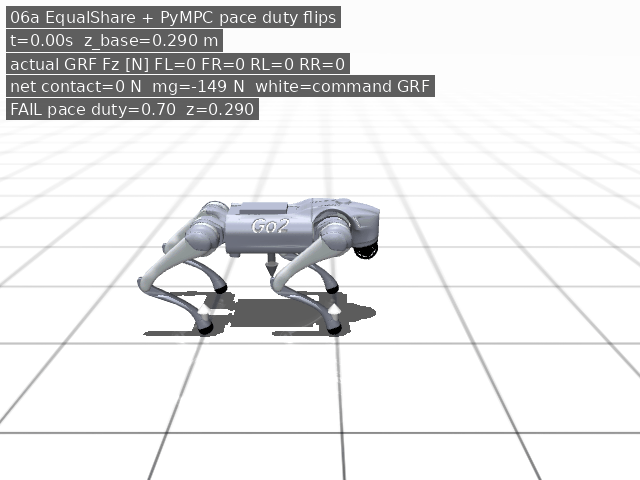

In [2]:
# --- このセルの意図 ---
# 試行 1: pace offset + 上流の低い duty。転ぶことをログと GIF で残す。

r_bad = rollout(freq=1.4, duty=0.70, off=np.array([0.8, 0.3, 0.8, 0.3]))
print("trial1 pympc-pace-duty  hold", r_bad["hold"], "zmin", r_bad["zmin"], "rpy", r_bad["maxr"])
print("trial1 FAIL expected:", r_bad["hold"] < HOLD_S)

bad = {"phi": np.array([0.8, 0.3, 0.8, 0.3], dtype=float), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3))}

def tau_bad(pl):
    """内容: 試行 1 と同じ。freq=1.4, duty=0.7, pace offset。"""
    dt = pl.sim_dt
    freq, duty = 1.4, 0.70
    if bad["lift"] is None:
        bad["lift"] = pl.feet_pos_world().copy()
        bad["z0"] = float(pl.base_pos()[2])
    geoms = pl.foot_geom_ids()
    phi = (bad["phi"] + dt * freq) % 1.0
    c = (phi < duty).astype(float)
    ns = max(float(c.sum()), 1.0)
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    fz_tot = pl.mass_kg * 9.81 + KP_Z * (bad["z0"] - z) - KD_Z * vz
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    cmd = np.zeros((4, 3))
    for i in range(4):
        if bad["prev"][i] > 0.5 and c[i] < 0.5:
            bad["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            F = np.array([0.0, 0.0, fz_tot / ns])
            cmd[i] = F
            tau[sl] = h[sl] - Jleg.T @ F
        else:
            s = float(np.clip((phi[i] - duty) / max(1e-6, 1.0 - duty), 0.0, 1.0))
            w = freq / max(1e-6, 1.0 - duty)
            p_d = bad["lift"][i].copy()
            p_d[2] = bad["lift"][i, 2] + STEP_H * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
            tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
    bad["phi"] = phi
    bad["prev"] = c
    bad["cmd"] = cmd
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant_f = MujocoGo2(scene="flat", seed=0)
n_gif = int(round(T_RUN / plant_f.sim_dt))
path_fail = render_rollout_gif(
    plant_f,
    Path("assets/06a_pace_low_duty.gif"),
    n_steps=n_gif,
    capture_every=80,
    tau_fn=tau_bad,
    command_grf=lambda pl: bad["cmd"],
    extra_lines=lambda pl: [f"FAIL pace duty=0.70  z={pl.base_pos()[2]:.3f}"],
    title="06a EqualShare + PyMPC pace duty flips",
)
print(path_fail.resolve(), path_fail.stat().st_size, "bytes")
display(Image(filename=str(path_fail)))


## 試行 2 — 表の duty / offset（仮説 2）

同じ直交 PD。名前では分岐しない。5 モードとも hold \(\ge 5\) s。


full_stance hold 7.0 zmin 0.28933837710855337 rpy 0.002520940878707253 xy 0.0007534658759116503 air [0.006 0.006 0.006 0.006]


trot hold 6.712 zmin 0.28896701624959226 rpy 0.5822583134630158 xy 0.03671301953241108 air [0.258 0.262 0.246 0.254]


crawl hold 6.244 zmin 0.28933837710855337 rpy 0.5279982301251609 xy 0.01564298930088873 air [0.102 0.114 0.132 0.13 ]


pace hold 7.0 zmin 0.2888400156025224 rpy 0.15130864365071206 xy 0.01508011202215084 air [0.064 0.034 0.09  0.062]


bound hold 7.0 zmin 0.28856621458408427 rpy 0.05337564161205817 xy 0.017927667767749473 air [0.076 0.076 0.092 0.066]
06 PASS: all five gaits held {'full_stance': 7.0, 'trot': 6.712, 'crawl': 6.244, 'pace': 7.0, 'bound': 7.0}


wrote /home/takuya/work/mpc_dog/notebook/assets/06_gait_contact.png


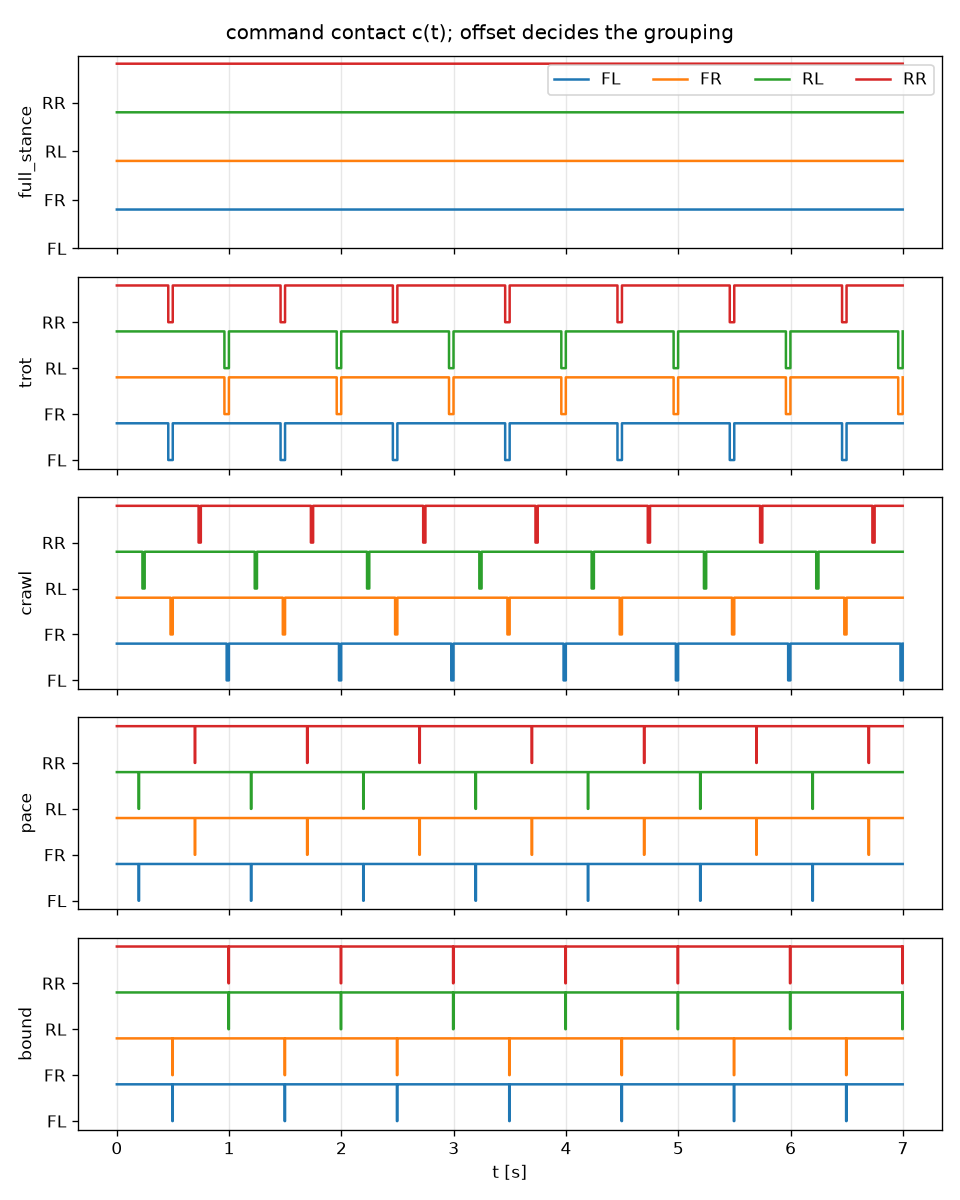

In [3]:
# --- このセルの意図 ---
# 試行 2: GAITS 表を回す。合格数字を assert する。接地 4 本線を図に残す。

results = {}
for name, g in GAITS.items():
    results[name] = rollout(g["freq"], g["duty"], g["off"])  # 内容: 制御 if 無し。表の数字だけ
    r = results[name]
    print(name, "hold", r["hold"], "zmin", r["zmin"], "rpy", r["maxr"], "xy", r["maxxy"], "air", np.round(r["meas_air"], 3))

for name, r in results.items():
    assert r["hold"] >= HOLD_S, f"{name} hold {r['hold']:.3f}s"
assert float(results["full_stance"]["meas_air"].max()) < 0.05
assert float(results["trot"]["meas_air"].min()) >= 0.15
print("06 PASS: all five gaits held", {k: results[k]["hold"] for k in GAITS})

# --- 接地 4 本線（指令 c）。混ぜない ---
fig, axes = plt.subplots(len(GAITS), 1, figsize=(8, 10), sharex=True)
legs = ["FL", "FR", "RL", "RR"]
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    t = np.arange(r["c"].shape[0]) * r["dt"]
    for i, leg in enumerate(legs):
        ax.plot(t, r["c"][:, i] * 0.8 + i, drawstyle="steps-post", label=leg)
    ax.set_yticks(range(4), legs)
    ax.set_ylabel(name)
    ax.grid(True, axis="x", alpha=0.3)
axes[-1].set_xlabel("t [s]")
axes[0].legend(loc="upper right", ncol=4)
fig.suptitle("command contact c(t); offset decides the grouping")
fig.tight_layout()
cpath = Path("assets/06_gait_contact.png")
fig.savefig(cpath, dpi=120)
plt.close(fig)
print("wrote", cpath.resolve())
display(Image(filename=str(cpath)))


成功側の GIF は crawl（trot は 05）。指令 GRF を載せる。


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/notebook/assets/06b_crawl.gif 1953202 bytes


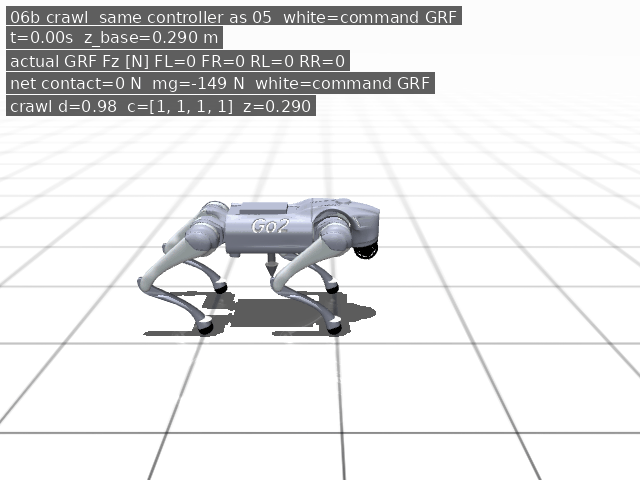

In [4]:
# --- このセルの意図 ---
# crawl の成功 GIF。白矢印は指令 GRF。trot の映像は 05b。

g = GAITS["crawl"]
okc = {"phi": g["off"].astype(float).copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3)), "c": np.ones(4)}

def tau_ok(pl):
    """内容: crawl の表どおり。05 と同じ tau。"""
    dt = pl.sim_dt
    freq, duty = g["freq"], g["duty"]
    if okc["lift"] is None:
        okc["lift"] = pl.feet_pos_world().copy()
        okc["z0"] = float(pl.base_pos()[2])
    geoms = pl.foot_geom_ids()
    phi = (okc["phi"] + dt * freq) % 1.0
    c = (phi < duty).astype(float)
    ns = max(float(c.sum()), 1.0)
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    fz_tot = pl.mass_kg * 9.81 + KP_Z * (okc["z0"] - z) - KD_Z * vz
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    cmd = np.zeros((4, 3))
    for i in range(4):
        if okc["prev"][i] > 0.5 and c[i] < 0.5:
            okc["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            F = np.array([0.0, 0.0, fz_tot / ns])
            cmd[i] = F
            tau[sl] = h[sl] - Jleg.T @ F
        else:
            s = float(np.clip((phi[i] - duty) / max(1e-6, 1.0 - duty), 0.0, 1.0))
            w = freq / max(1e-6, 1.0 - duty)
            p_d = okc["lift"][i].copy()
            p_d[2] = okc["lift"][i, 2] + STEP_H * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
            tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
    okc["phi"] = phi
    okc["prev"] = c
    okc["c"] = c
    okc["cmd"] = cmd
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant = MujocoGo2(scene="flat", seed=0)
n_gif = int(round(T_RUN / plant.sim_dt))
path = render_rollout_gif(
    plant,
    Path("assets/06b_crawl.gif"),
    n_steps=n_gif,
    capture_every=80,
    tau_fn=tau_ok,
    command_grf=lambda pl: okc["cmd"],
    extra_lines=lambda pl: [f"crawl d=0.98  c={okc['c'].astype(int).tolist()}  z={pl.base_pos()[2]:.3f}"],
    title="06b crawl  same controller as 05  white=command GRF",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析

- 試行 1: ペース offset でも duty が低いと EqualShare は左右に倒れる。GIF `06a`
- 試行 2: 同じ \(\tau\) で、offset が組を決め、duty が overlap を決める。5 モードとも 5 秒。図 `06_gait_contact.png`、GIF `06b`
- `full_stance` は空中時間がほぼ 0（S1 回帰）

## 次の仮説

ごく小さい \(v_x\) を足す。着地 xy はまだ今の足の位置のまま。胴体がゆっくり前へずれる。
